In [1]:
# Libraries Import
import os
import random
import numpy as np
import torch
import json
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import timm
from PIL import Image

from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim


In [2]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

In [3]:
import os

dataset_path = "/kaggle/input"

print(os.listdir(dataset_path))


['google-data-testing', 'testingdisease', 'fine-tune-dataset', 'new-plant-diseases-dataset']


In [4]:
['new-plant-diseases-dataset']

['new-plant-diseases-dataset']

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
import os
dataset_dir = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
disease_categories = os.listdir(dataset_dir)

print("Classes of Diseases:\n")
for category in disease_categories:
    print(category)

print(f"\n Total Categories: {len(disease_categories)}")


Classes of Diseases:

Tomato___Late_blight
Tomato___healthy
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Soybean___healthy
Squash___Powdery_mildew
Potato___healthy
Corn_(maize)___Northern_Leaf_Blight
Tomato___Early_blight
Tomato___Septoria_leaf_spot
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Strawberry___Leaf_scorch
Peach___healthy
Apple___Apple_scab
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Bacterial_spot
Apple___Black_rot
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Peach___Bacterial_spot
Apple___Cedar_apple_rust
Tomato___Target_Spot
Pepper,_bell___healthy
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Potato___Late_blight
Tomato___Tomato_mosaic_virus
Strawberry___healthy
Apple___healthy
Grape___Black_rot
Potato___Early_blight
Cherry_(including_sour)___healthy
Corn_(maize)___Common_rust_
Grape___Esca_(Black_Measles)
Raspberry___healthy
Tomato___Leaf_Mold
Tomato___Spider_mites Two-spotted_spider_mite
Pepper,_bell___Bacterial_spot
Corn_(maize)___he

In [7]:
print(os.listdir("/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"))
print(len(os.listdir("/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train")))


['valid', 'train']
38


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_path = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

categories = os.listdir(dataset_path)

def show_images(category, n_images):
    shapes = [] 
    image_folder_path = os.path.join(dataset_path, category)

    # Get list of images, handle empty categories
    image_files = os.listdir(image_folder_path)[:n_images]
    if len(image_files) == 0:
        print(f" Warning: No images found in category '{category}'")
        return

    # Ensure subplot axes is a list (for single image case)
    fig, axes = plt.subplots(1, len(image_files), figsize=(15, 20))
    if len(image_files) == 1:
        axes = [axes]

    for i, image_file in enumerate(image_files):
        img_path = os.path.join(image_folder_path, image_file)

        img = cv2.imread(img_path)
        if img is None:
            print(f" Warning: Could not read image: {img_path}")
            continue

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        shapes.append(img.shape)

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(category)

    plt.tight_layout()
    plt.show()

    print(f" {category}: Image Shapes = {shapes}")

for category in categories:
    show_images(category, 2)


In [ ]:
dataset_path="/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
categories=os.listdir(dataset_path)
image_counts_list=[]
# Visulizing the counts of images per category
for category in categories:
 image_folder=os.path.join(dataset_path,category)
 image_counts=len(os.listdir(image_folder))
 image_counts_list.append(image_counts)
plt.figure(figsize=(12,10))
plt.bar(categories,image_counts_list,color='skyblue')
plt.xlabel("Disease Category")
plt.xticks(rotation=90)
plt.yticks(np.arange(0, max(image_counts_list) + 50, 50))
plt.ylabel("Number of Images")
plt.title("Number of Images per Disease Class")
plt.show()

# Data Preprocessing

In [8]:
# Enhanced data augmentation for training
transform_train = transforms.Compose([
    transforms.RandomResizedCrop((256, 256), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# Validation transform (no augmentation)
transform_val = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])
# Define the path to your dataset folder
train_folder = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

# full training dataset with training augmentation
full_dataset = datasets.ImageFolder(root=train_folder, transform=transform_train)
print("Total images in dataset:", len(full_dataset))
print("Class mapping:", full_dataset.class_to_idx)

# validation
val_dataset_full = datasets.ImageFolder(root=train_folder, transform=transform_val)


Total images in dataset: 70295
Class mapping: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_bl

In [9]:
# Split dataset into train and validation (80/20 split)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, _ = random_split(full_dataset, [train_size, val_size])
_, val_dataset = random_split(val_dataset_full, [train_size, val_size])
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,num_workers=2, pin_memory=True)
print("Total training batches:", len(train_loader))

Training samples: 56236
Validation samples: 14059
Total training batches: 1758


In [ ]:
batch_images, batch_labels = next(iter(train_loader))

# Check min & max pixel values in the batch (values should be between -1 and 1 after normalization, so we reverse it)
print("Min pixel value:", torch.min(batch_images).item())
print("Max pixel value:", torch.max(batch_images).item())
print("Total batches in train_loader:", len(train_loader))

# 5 imgs
for i in range(min(5, batch_images.size(0))):

    img_tensor = batch_images[i]
    img_np = img_tensor.cpu().numpy().transpose(1, 2, 0)
# normalisation reverse
    img_np = (img_np * 0.5) + 0.5 
    
    plt.imshow(img_np)
    print("Image shape:", img_np.shape)
    print("Label:", batch_labels[i].item())
    plt.axis("off")
    plt.show()

# Model

In [10]:
# Model 
num_classes = len(full_dataset.classes)
model = timm.create_model('convmixer_1024_20_ks9_p14.in1k', pretrained=True, num_classes=num_classes)
model = model.to(device)
# print(model)


In [11]:
# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Epoch [1/3] Train Loss: 0.2295, Train Accuracy: 93.19%


Epoch [1/3] Val Loss: 0.0724, Val Accuracy: 97.66%



Epoch [2/3] Train Loss: 0.0958, Train Accuracy: 96.98%


Epoch [2/3] Val Loss: 0.0605, Val Accuracy: 97.89%



Epoch [3/3] Train Loss: 0.0810, Train Accuracy: 97.36%


Epoch [3/3] Val Loss: 0.0683, Val Accuracy: 98.06%



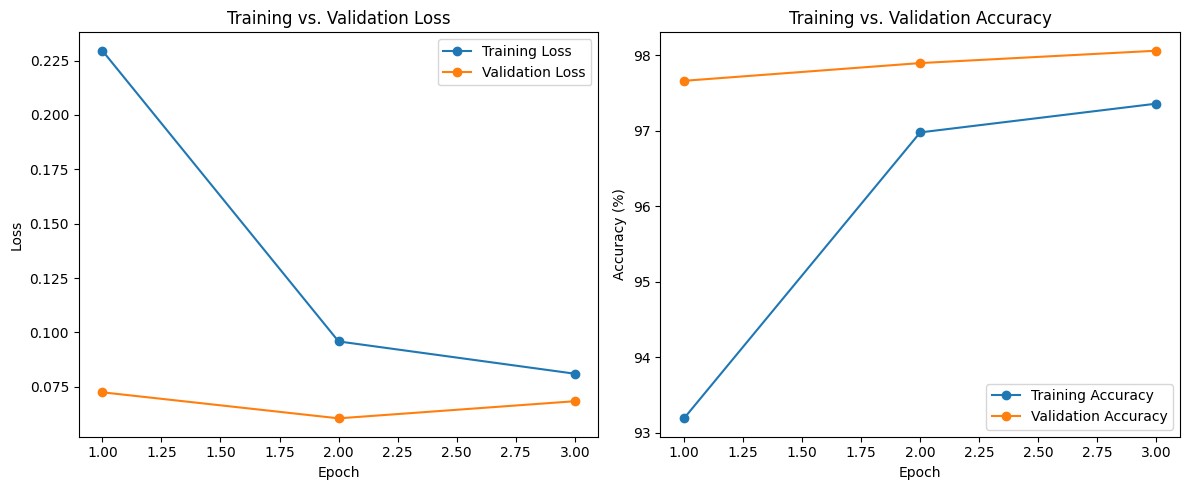

In [12]:
#training & validation
epochs = 3

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    # training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # tqdm progress bar
    train_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{epochs}", leave=False)
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += batch_size
        
        # progress bar 
        current_loss = running_loss / total
        current_acc = correct / total * 100
        train_bar.set_postfix({"Train Loss": f"{current_loss:.4f}", "Train Acc": f"{current_acc:.2f}%"})
    
    train_loss = running_loss / len(train_dataset)
    train_accuracy = correct / len(train_dataset) * 100
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")
    
    # validation

    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    val_bar = tqdm(val_loader, desc="Validating", leave=False)
    with torch.no_grad():
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            batch_size = images.size(0)
            running_val_loss += loss.item() * batch_size
            correct_val += (outputs.argmax(dim=1) == labels).sum().item()
            total_val += batch_size
            
            current_val_loss = running_val_loss / total_val
            current_val_acc = correct_val / total_val * 100
            val_bar.set_postfix({"Val Loss": f"{current_val_loss:.4f}", "Val Acc": f"{current_val_acc:.2f}%"})
    
    val_loss = running_val_loss / len(val_dataset)
    val_accuracy = correct_val / len(val_dataset) * 100
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    print(f"Epoch [{epoch+1}/{epochs}] Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%\n")

#train vs validation plot
epochs_range = range(1, epochs+1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Training Loss", marker='o')
plt.plot(epochs_range, val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss")
plt.legend()

# Accuracy 
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label="Training Accuracy", marker='o')
plt.plot(epochs_range, val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs. Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
all_preds = []
all_labels = []

model.eval() 
with torch.no_grad():
    for inputs, labels in val_loader: 
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs) 
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = train_dataset.dataset.classes  

print("Classes:", class_names)

In [ ]:
# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
#Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Model on Plant Diseases")
plt.show()

# Testing

In [13]:
model.eval()
running_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += batch_size

val_loss = running_loss / total
val_accuracy = correct / total

print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy * 100:.2f}%")


Validation Loss: 0.0683, Validation Accuracy: 98.06%


In [14]:
def preprocess_image(image_path, target_size=(256, 256)):

    img = cv2.imread(image_path)
    # BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    pil_img = Image.fromarray(img)
    
    transform = transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize(mean=[0.5, 0.5, 0.5],
                             std=[0.5, 0.5, 0.5])
    ])
    #transforms
    tensor_img = transform(pil_img)
    tensor_img = tensor_img.unsqueeze(0)
    return tensor_img

In [15]:
def predict(model, image_path, idx_to_class, device='cuda'):
    # Preprocess
    processed_img = preprocess_image(image_path)
    processed_img = processed_img.to(device)
    
    # Set model
    model.eval()
    with torch.no_grad():
        outputs = model(processed_img)

    predicted_class_index = outputs.argmax(dim=1).item()
    # Map index to class
    predicted_class_name = idx_to_class[predicted_class_index]
    return predicted_class_name

In [16]:
#testing on test dataset
idx_to_class = {v: k for k, v in train_dataset.dataset.class_to_idx.items()}

image_path = "/kaggle/input/new-plant-diseases-dataset/test/test/PotatoHealthy1.JPG"
predicted_class = predict(model, image_path, idx_to_class, device='cuda')
print("Predicted class:", predicted_class)

Predicted class: Potato___healthy


In [17]:
# testing on google dataset
uploaded_image_path = "/kaggle/input/testingdisease/TomatoEarlyBlight2.png" 
idx_to_class = {v: k for k, v in train_dataset.dataset.class_to_idx.items()}

predicted_class = predict(model, uploaded_image_path, idx_to_class, device='cuda')
print("Predicted class:", predicted_class)


Predicted class: Corn_(maize)___Common_rust_


In [22]:
# Save the model's state dictionary
torch.save(model.state_dict(), "/kaggle/working/plant_disease_model.pth")
print("Model saved successfully!")

Model saved successfully!


In [23]:
import pickle

In [25]:
class_mapping = full_dataset.class_to_idx  
with open("/kaggle/working/class_mapping.json", "w") as f:
    json.dump(class_mapping, f)

print("Class mapping saved:", class_mapping)

Class mapping saved: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late

In [26]:
with open("/kaggle/working/plant_disease_model-main.pkl", "wb") as f:
    pickle.dump(model, f)
print("Model saved using pickle")

Model saved using pickle


# Fine Tuning

In [19]:
fine_tune_path = "/kaggle/input/fine-tune-dataset"  

# transforms
transform_fine_tune = transforms.Compose([
    transforms.Resize((256, 256)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

fine_tune_dataset = datasets.ImageFolder(root=fine_tune_path, transform=transform_fine_tune)

external_loader = DataLoader(fine_tune_dataset, batch_size=32, shuffle=True, num_workers=2)

print(f"Found {len(fine_tune_dataset)} images in the fine-tune dataset.")
print(f"Classes: {fine_tune_dataset.classes}")

Found 614 images in the fine-tune dataset.
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot_Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper_bell___Bacterial_spot', 'Pepper_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_m

In [29]:
fine_tune_epochs = 22
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # Lower LR for fine-tuning

# -------------------------
# 4) Fine-Tuning Loop
# -------------------------
print("Starting fine-tuning on external data...")
for epoch in range(fine_tune_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in external_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Zero out gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        
        # Compute loss
        loss = criterion(outputs, labels)
        
        # Backpropagation
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Update metrics
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += batch_size
    
    # Compute epoch metrics
    epoch_loss = running_loss / total
    epoch_acc = correct / total * 100
    print(f"Fine-tune Epoch [{epoch+1}/{fine_tune_epochs}] "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

print("Fine-tuning complete.")

Starting fine-tuning on external data...
Fine-tune Epoch [1/22] Loss: 1.7773, Acc: 51.47%
Fine-tune Epoch [2/22] Loss: 1.4153, Acc: 60.10%
Fine-tune Epoch [3/22] Loss: 1.2376, Acc: 62.87%
Fine-tune Epoch [4/22] Loss: 1.0473, Acc: 70.20%
Fine-tune Epoch [5/22] Loss: 0.8986, Acc: 71.66%
Fine-tune Epoch [6/22] Loss: 0.7710, Acc: 75.73%
Fine-tune Epoch [7/22] Loss: 0.7171, Acc: 75.08%
Fine-tune Epoch [8/22] Loss: 0.6534, Acc: 76.22%
Fine-tune Epoch [9/22] Loss: 0.5732, Acc: 79.97%
Fine-tune Epoch [10/22] Loss: 0.5554, Acc: 79.48%
Fine-tune Epoch [11/22] Loss: 0.5158, Acc: 80.78%
Fine-tune Epoch [12/22] Loss: 0.5010, Acc: 79.97%
Fine-tune Epoch [13/22] Loss: 0.4297, Acc: 82.25%
Fine-tune Epoch [14/22] Loss: 0.4311, Acc: 80.13%
Fine-tune Epoch [15/22] Loss: 0.4366, Acc: 80.78%
Fine-tune Epoch [16/22] Loss: 0.4134, Acc: 81.60%
Fine-tune Epoch [17/22] Loss: 0.4177, Acc: 79.97%
Fine-tune Epoch [18/22] Loss: 0.4007, Acc: 82.41%
Fine-tune Epoch [19/22] Loss: 0.4037, Acc: 81.27%
Fine-tune Epoch [2

In [33]:
def tta_predict(model, image_path, idx_to_class, device='cuda', tta_runs=5):
    base_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5],
                             std=[0.5, 0.5, 0.5])
    ])
    tta_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)
    ])
    
    pil_img = Image.open(image_path).convert("RGB")
    predictions = []
    model.eval()
    with torch.no_grad():
        for _ in range(tta_runs):
            aug_img = tta_transform(pil_img)
            input_tensor = base_transform(aug_img).unsqueeze(0).to(device)
            outputs = model(input_tensor)
            predictions.append(outputs)
    avg_outputs = torch.mean(torch.stack(predictions), dim=0)
    predicted_index = avg_outputs.argmax(dim=1).item()
    return idx_to_class[predicted_index]

In [45]:
google_image_path="/kaggle/input/google-data-testing/AppleCedarRust.jpg"
predicted_class_tta = tta_predict(model, google_image_path, idx_to_class, device=device, tta_runs=5)
print("Predicted class with TTA on Google image:", predicted_class_tta)

Predicted class with TTA on Google image: Apple___Cedar_apple_rust


# Saving Model

In [ ]:
# Save the model's state dictionary to /kaggle/working
torch.save(model.state_dict(), "/kaggle/working/plant_disease_model_fine_tuned.pth")
print("Model saved successfully!")

In [ ]:
import pickle

In [ ]:
class_mapping = dataset.class_to_idx  
with open("/kaggle/working/class_mapping_fine_tuned.json", "w") as f:
    json.dump(class_mapping, f)

print("Class mapping saved:", class_mapping)

In [ ]:
with open("/kaggle/working/plant_disease_model-main_fine_tunes.pkl", "wb") as f:
    pickle.dump(model, f)
print("Model saved using pickle")